In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Customer_data.csv to Customer_data.csv


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving internet_data.csv to internet_data.csv


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Churn_data.csv to Churn_data.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt                                                                #Import Libraries
import seaborn as sns

In [ ]:
customer = pd.read_csv('Customer_data.csv')
internet = pd.read_csv('internet_data.csv')                                                    #Load Data
churn = pd.read_csv('Churn_data.csv')

In [ ]:
customer.head()
internet.head()                                                                            #Data Understanding (View Data)
churn.head()

,customerID,tenure,PhoneService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,1,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,34,Yes,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,2,Yes,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,45,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,2,Yes,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
customer.info()
internet.info()                                                                              #Data Understanding (Check Structure)
churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   customerID     7043 non-null   object 
 1   gender         7043 non-null   object 
 2   SeniorCitizen  0 non-null      float64
 3   Partner        7043 non-null   object 
 4   Dependents     7043 non-null   object 
 5   Day            7043 non-null   int64  
 6   year           7043 non-null   int64  
 7   month          7043 non-null   int64  
dtypes: float64(1), int64(3), object(4)
memory usage: 440.3+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        7043 non-null   object
 1   MultipleLines     7043 non-null   object
 2   InternetService   7043 non-null   object
 3   OnlineSecurity    5517 non-null   object
 4   Onl

In [ ]:
customer.describe()                                                               #Data Understanding (Statistical Summary)

,SeniorCitizen,Day,year,month
count,0.0,7043.000000,7043.000000,7043.000000
mean,NaN,15.443277,1996.036490,6.563396
std,NaN,8.693037,9.505657,3.432856
min,NaN,1.000000,1980.000000,1.000000
25%,NaN,8.000000,1988.000000,4.000000
50%,NaN,16.000000,1996.000000,7.000000
75%,NaN,23.000000,2004.000000,10.000000
max,NaN,30.000000,2012.000000,12.000000


In [ ]:
df = pd.merge(customer, internet, on='customerID')                                     #Merge Dataset
df = pd.merge(df, churn, on='customerID')

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,Day,year,month,MultipleLines,InternetService,...,StreamingTV,StreamingMovies,tenure,PhoneService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,NaN,Yes,No,29,1998,1,No phone service,DSL,...,No,No,1,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,NaN,No,No,12,1983,9,No,DSL,...,No,No,34,Yes,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,NaN,No,No,15,1996,5,No,DSL,...,No,No,2,Yes,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,NaN,No,No,19,2001,2,No phone service,DSL,...,No,No,45,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,NaN,No,No,23,1980,12,No,Fiber optic,...,No,No,2,Yes,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.isnull().sum()                                                                                    #Data Quality check (Missing Values)

,0
customerID,0
gender,0
SeniorCitizen,7043
Partner,0
Dependents,0
Day,0
year,0
month,0
MultipleLines,0
InternetService,0


In [ ]:
df.duplicated().sum()                                                                       #Data Quality check (Duplicates)

np.int64(0)

In [ ]:
df.nunique()                                                                              #Data Quality check (Unique Values)

,0
customerID,7043
gender,2
SeniorCitizen,0
Partner,2
Dependents,2
Day,30
year,33
month,12
MultipleLines,3
InternetService,3


In [ ]:
df = df.dropna()                                                                               #Data Cleaning (handle missing values)

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')                        #Data Cleaning (Fix Data Types)

In [ ]:
df.drop_duplicates(inplace=True)                                                              #Data Cleaning (Remove duplicates)

,customerID,gender,SeniorCitizen,Partner,Dependents,Day,year,month,MultipleLines,InternetService,...,StreamingTV,StreamingMovies,tenure,PhoneService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [ ]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})                                 #Data Transformation (Convert categorical → numeric)

In [ ]:
df.shape                                                                         #Check data

(0, 24)

In [ ]:
print(customer.columns)                                                             #Check column names
print(internet.columns)
print(churn.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'Day',
       'year', 'month'],
      dtype='object')
Index(['customerID', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies'],
      dtype='object')
Index(['customerID', 'tenure', 'PhoneService', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [ ]:
customer.rename(columns={'customerId':'customerID'}, inplace=True)
internet.rename(columns={'customerId':'customerID'}, inplace=True)               # Standardize column name
churn.rename(columns={'customerId':'customerID'}, inplace=True)

In [ ]:
customer['customerID'] = customer['customerID'].str.strip()
internet['customerID'] = internet['customerID'].str.strip()                      #Remove spaces
churn['customerID'] = churn['customerID'].str.strip()

In [ ]:
customer['customerID'] = customer['customerID'].astype(str)
internet['customerID'] = internet['customerID'].astype(str)                      #Ensure same data type
churn['customerID'] = churn['customerID'].astype(str)

In [ ]:
set(customer['customerID']).intersection(set(internet['customerID']))            #Check Common IDs

{'6586-PSJOX',
 '6976-BWGLQ',
 '7009-LGECI',
 '4767-HZZHQ',
 '3785-NRHYR',
 '1478-VPOAD',
 '4536-PLEQY',
 '7394-LWLYN',
 '6732-FZUGP',
 '2001-EWBQU',
 '8835-VSDSE',
 '4039-HEUNW',
 '2612-RRIDN',
 '0269-XFESX',
 '9565-DJPIB',
 '2863-IMQDR',
 '0112-QWPNC',
 '6217-KDYWC',
 '4710-FDUIZ',
 '6621-YOBKI',
 '9940-RHLFB',
 '3696-DFHHB',
 '4250-ZBWLV',
 '3675-EQOZA',
 '3703-KBKZP',
 '6275-YDUVO',
 '6794-HKIAJ',
 '6629-CZTTH',
 '2904-GGUAZ',
 '2817-LVCPP',
 '5150-LJNSR',
 '2274-XUATA',
 '8648-PFRMP',
 '7306-YDSOI',
 '1629-DQQVB',
 '7537-CBQUZ',
 '9398-MMQTO',
 '2498-XLDZR',
 '1697-NVVGY',
 '8164-OCKUJ',
 '5846-ABOBJ',
 '9577-WJVCQ',
 '2387-KDZQY',
 '6641-XRPSU',
 '6765-MBQNU',
 '1302-TPUBN',
 '2911-UREFD',
 '2305-MRGLV',
 '0003-MKNFE',
 '4043-MKDTV',
 '4735-ASGMA',
 '0022-TCJCI',
 '5302-BDJNT',
 '4778-IZARL',
 '3339-EAQNV',
 '2474-BRUCM',
 '7502-BNYGS',
 '8777-MBMTS',
 '0650-BWOZN',
 '4644-PIZRT',
 '1383-EZRWL',
 '2284-VFLKH',
 '1038-ZAGBI',
 '2811-POVEX',
 '2070-FNEXE',
 '6410-LEFEN',
 '7789-CRU

In [ ]:
df = pd.merge(customer, internet, on='customerID', how='inner')                         #Merge Again (in a proper way)
df = pd.merge(df, churn, on='customerID', how='inner')

In [ ]:
df.shape                                                                              #Verify
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,Day,year,month,MultipleLines,InternetService,...,StreamingTV,StreamingMovies,tenure,PhoneService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,NaN,Yes,No,29,1998,1,No phone service,DSL,...,No,No,1,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,NaN,No,No,12,1983,9,No,DSL,...,No,No,34,Yes,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,NaN,No,No,15,1996,5,No,DSL,...,No,No,2,Yes,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,NaN,No,No,19,2001,2,No phone service,DSL,...,No,No,45,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,NaN,No,No,23,1980,12,No,Fiber optic,...,No,No,2,Yes,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


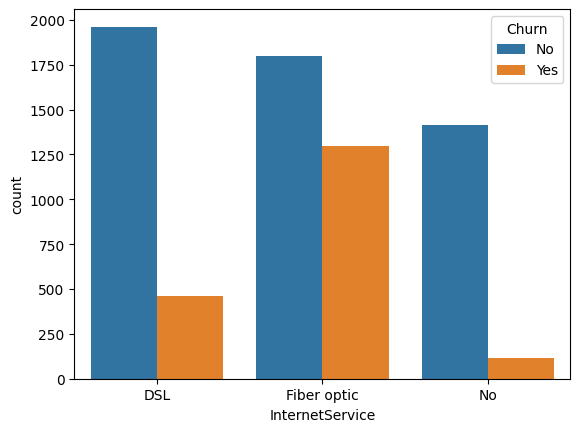

In [ ]:
sns.countplot(x='InternetService', hue='Churn', data=df)                           #BIVARIATE ANALYSIS (Internet Service vs Churn)
plt.show()                                                                         #Insights : Fiber optic users show higher churn compared to DSL users.

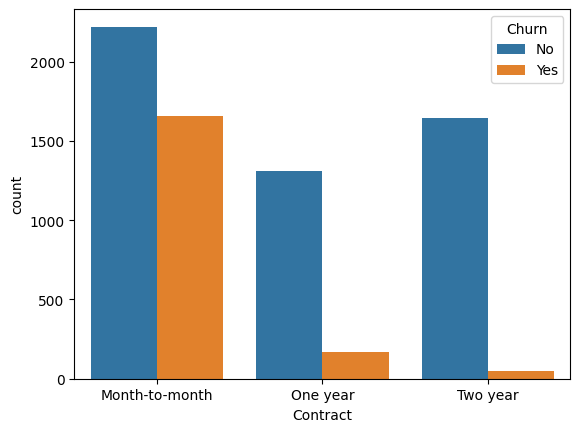

In [ ]:
sns.countplot(x='Contract', hue='Churn', data=df)                                     #Contract vs Churn
plt.show()                                                                            #Insights : Month-to-month customers churn the most.

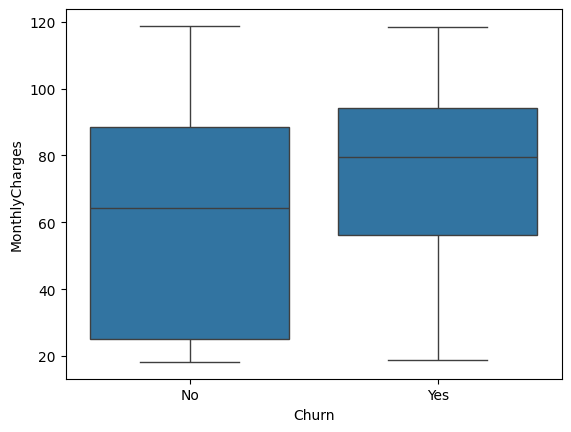

In [ ]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)                                   #Monthly Charges vs Churn
plt.show()                                                                            #Insights : Higher charges → higher churn probability

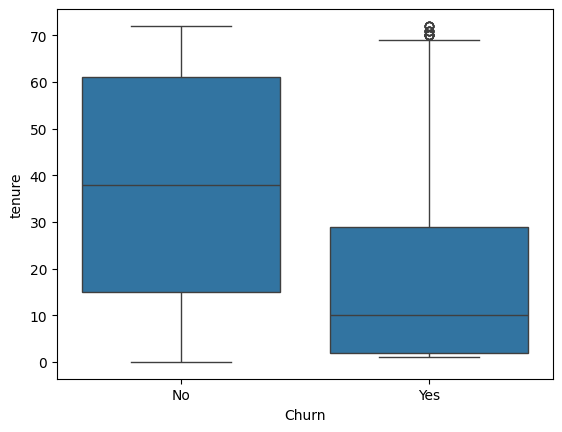

In [ ]:
sns.boxplot(x='Churn', y='tenure', data=df)                                             # Tenure vs Churn
plt.show()                                                                              # Insights : Low tenure customers churn more

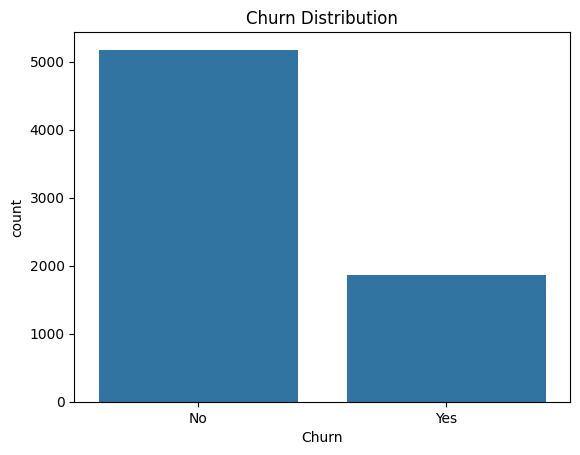

In [ ]:
sns.countplot(x='Churn', data=df)                                                  #UNIVARIATE ANALYSIS : CATEGORICAL VARIABLES (Churn Distribution)
plt.title("Churn Distribution")                                                    # Insights : Shows how many customers churned vs stayed
plt.show()

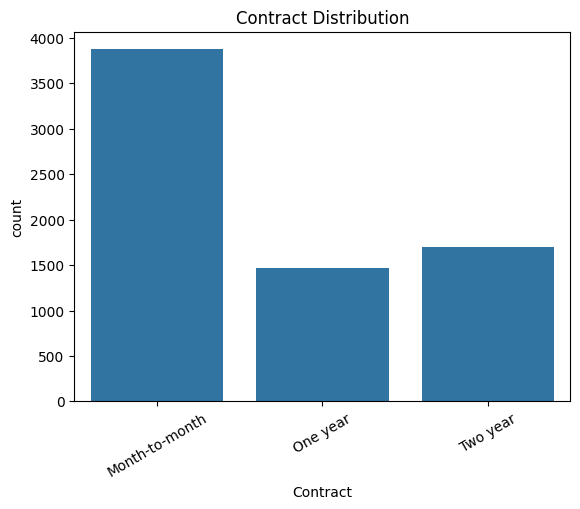

In [ ]:
sns.countplot(x='Contract', data=df)                                                #Contract Type
plt.title("Contract Distribution")                                                  # Insights : Most customers are on month-to-month contracts
plt.xticks(rotation=30)
plt.show()

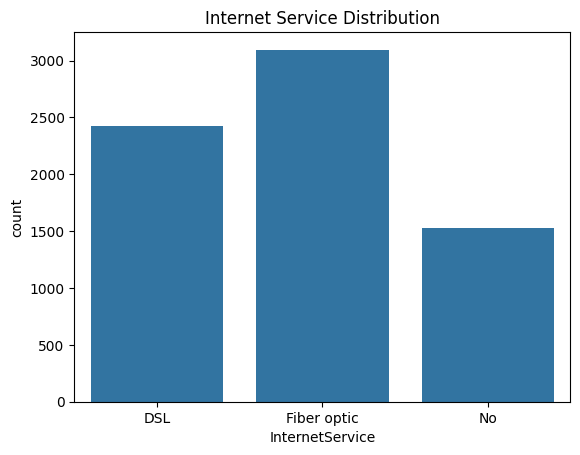

In [ ]:
sns.countplot(x='InternetService', data=df)                                           #Internet Service
plt.title("Internet Service Distribution")                                            # Insights :
plt.show()

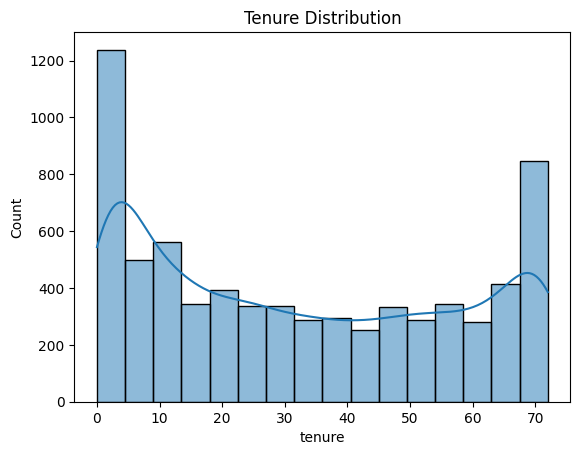

In [ ]:
sns.histplot(df['tenure'], kde=True)                                              #UNIVARIATE ANALYSIS : NUMERICAL VARIABLES (Tenure Distribution)
plt.title("Tenure Distribution")                                                  #Insights : Most customers have low tenure
plt.show()

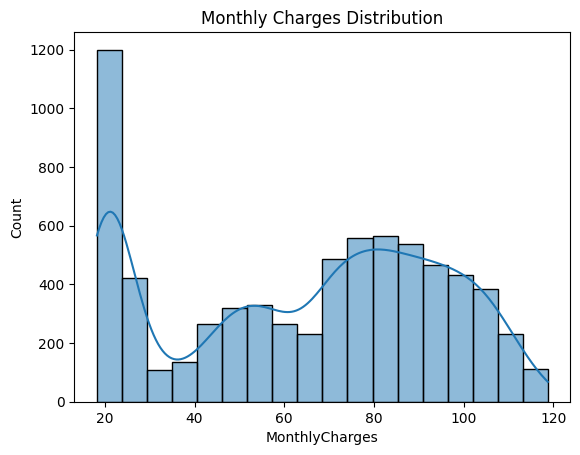

In [ ]:
sns.histplot(df['MonthlyCharges'], kde=True)
plt.title("Monthly Charges Distribution")                                            #Monthly Charges
plt.show()

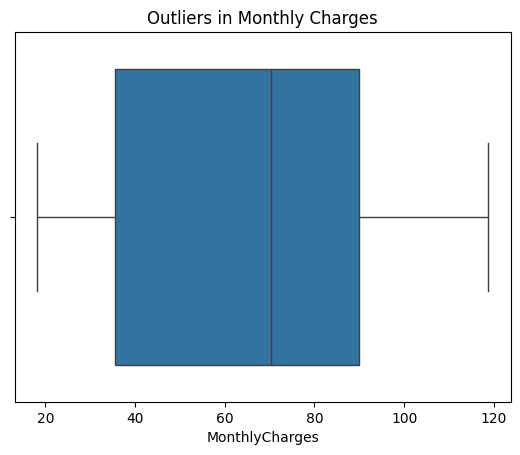

In [ ]:
sns.boxplot(x=df['MonthlyCharges'])
plt.title("Outliers in Monthly Charges")                                          #Boxplot (Outliers)
plt.show()

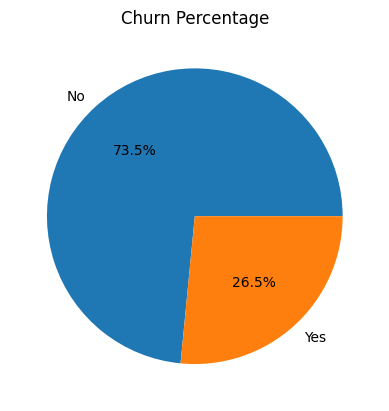

In [ ]:
df['Churn'].value_counts().plot(kind='pie', autopct='%1.1f%%')                        #MATPLOTLIB - UNIVARIATE (Pie chart:churn)
plt.title("Churn Percentage")
plt.ylabel('')
plt.show()

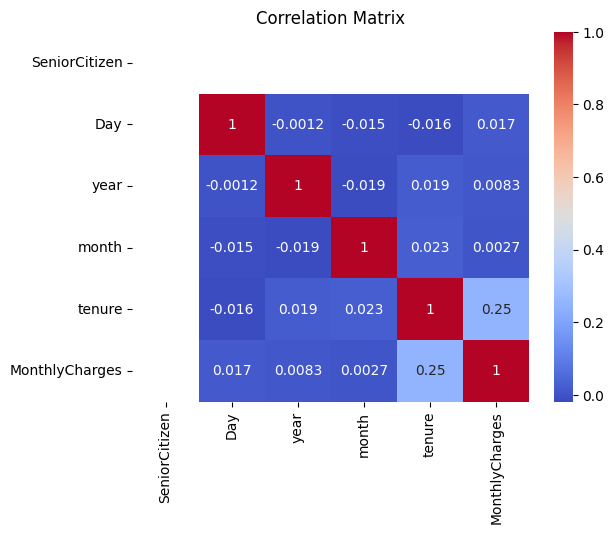

In [ ]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])                        #MULTIVARIATE ANALYSIS (HEATMAP : CORRELATION : Shows relationships between numerical variables)

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

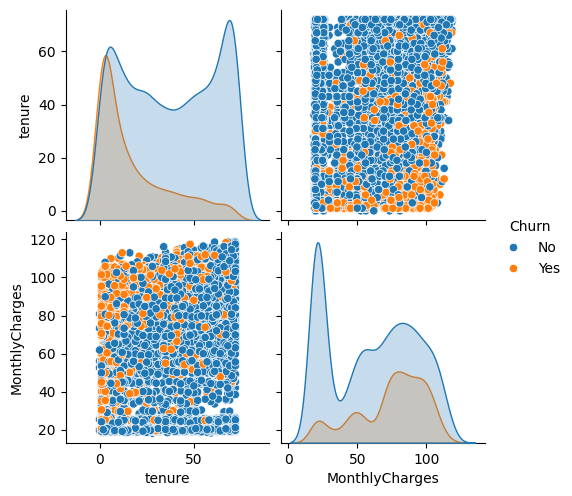

In [ ]:
sns.pairplot(df[['tenure','MonthlyCharges','TotalCharges','Churn']], hue='Churn')        #PAIRPLOT (MULTI RELATION)
plt.show()                                                                               #Shows patterns & clusters

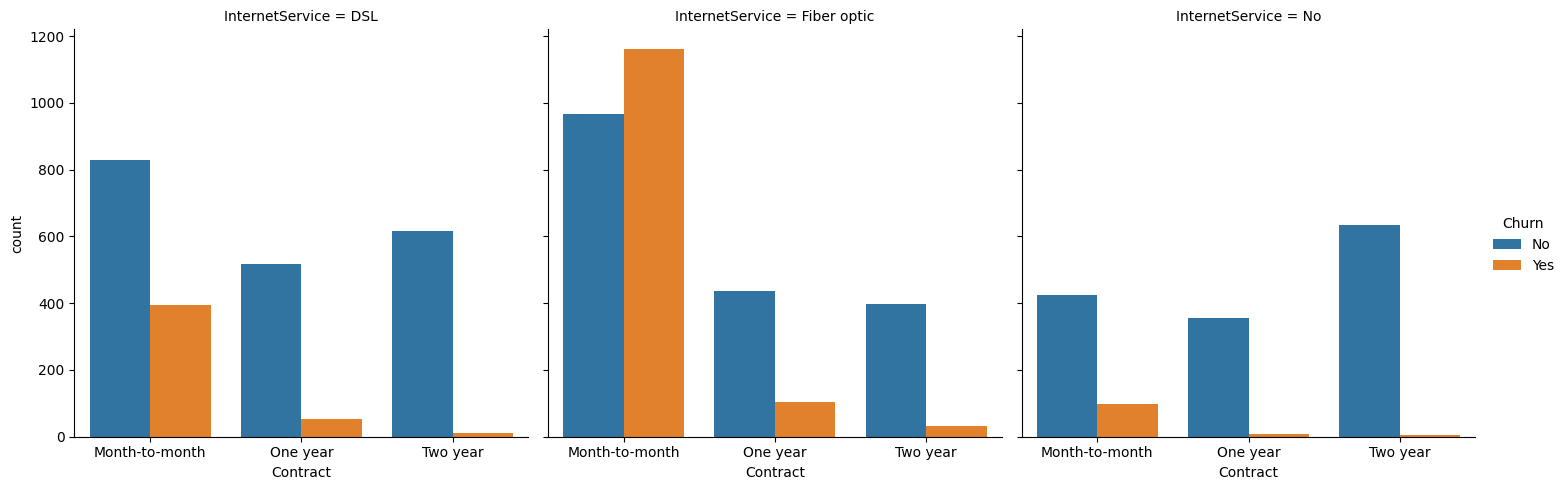

In [ ]:
sns.catplot(x='Contract', hue='Churn', col='InternetService',                          #MULTI CATEGORY ANALYSIS (Contract + InternetService + Churn)
            data=df, kind='count')                                                     #Shows churn behavior across multiple categories

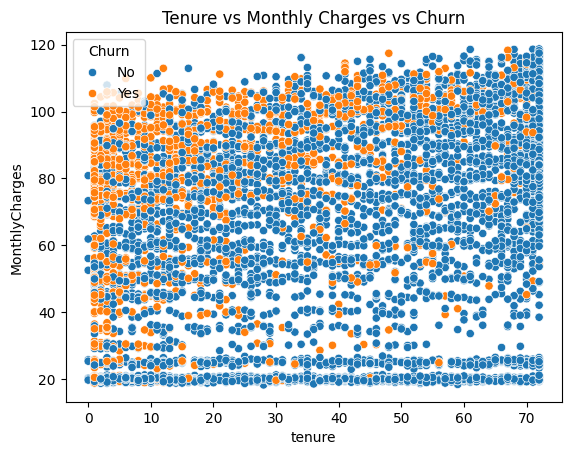

In [ ]:
sns.scatterplot(x='tenure', y='MonthlyCharges', hue='Churn', data=df)                #SCATTER (3 VARIABLES)
plt.title("Tenure vs Monthly Charges vs Churn")
plt.show()

In [ ]:
customer = pd.read_csv('Customer_data.csv')
internet = pd.read_csv('internet_data.csv')
churn = pd.read_csv('Churn_data.csv')

In [ ]:
churn['Churn'].unique()

array(['No', 'Yes'], dtype=object)

In [ ]:
churn['Churn'] = churn['Churn'].astype(str).str.strip()

In [ ]:
df = customer.merge(internet, on='customerID', how='inner') \
             .merge(churn, on='customerID', how='inner')

In [ ]:
df['Churn'].unique()

array(['No', 'Yes'], dtype=object)

In [ ]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [ ]:
df['Churn'].value_counts()

,count
Churn,
0,5174
1,1869


In [ ]:
result = df.groupby(['InternetService', 'Contract'])['Churn'].mean().reset_index()          #Identifies high-risk combinations
result['Churn %'] = result['Churn'] * 100
result

,InternetService,Contract,Churn,Churn %
0,DSL,Month-to-month,0.322159,32.215863
1,DSL,One year,0.092982,9.298246
2,DSL,Two year,0.019108,1.910828
3,Fiber optic,Month-to-month,0.546053,54.605263
4,Fiber optic,One year,0.192950,19.294991
5,Fiber optic,Two year,0.072261,7.226107
6,No,Month-to-month,0.188931,18.893130
7,No,One year,0.024725,2.472527
8,No,Two year,0.007837,0.783699


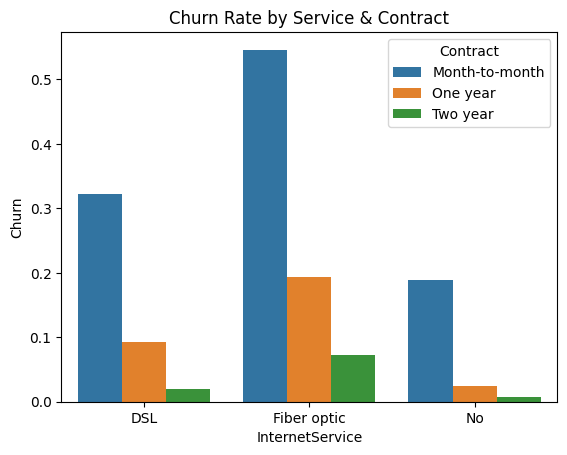

In [ ]:
sns.barplot(x='InternetService', y='Churn', hue='Contract', data=result)
plt.title("Churn Rate by Service & Contract")
plt.show()

In [ ]:
avg_charge = df['MonthlyCharges'].mean()
print(avg_charge)                                                                           #Average Monthly Charges

64.76169246059918


In [ ]:
def risk_category(row):
    if (row['Churn'] == 'Yes') and (row['tenure'] < 12) and (row['MonthlyCharges'] > avg_charge):
        return 'High Risk'

    elif (row['Churn'] == 'Yes') and (12 <= row['tenure'] <= 24):                               #Create Risk Category Function
        return 'Medium Risk'

    else:
        return 'Low Risk'

In [ ]:
df['Risk_category'] = df.apply(risk_category, axis=1)

In [ ]:
risk_df = df[['customerID', 'tenure', 'MonthlyCharges', 'Risk_category']]
risk_df.head()

,customerID,tenure,MonthlyCharges,Risk_category
0,7590-VHVEG,1,29.85,Low Risk
1,5575-GNVDE,34,56.95,Low Risk
2,3668-QPYBK,2,53.85,Low Risk
3,7795-CFOCW,45,42.30,Low Risk
4,9237-HQITU,2,70.70,Low Risk


In [ ]:
df['Risk_category'].value_counts()                                                    #Count of Each Risk Category

,count
Risk_category,
Low Risk,7043


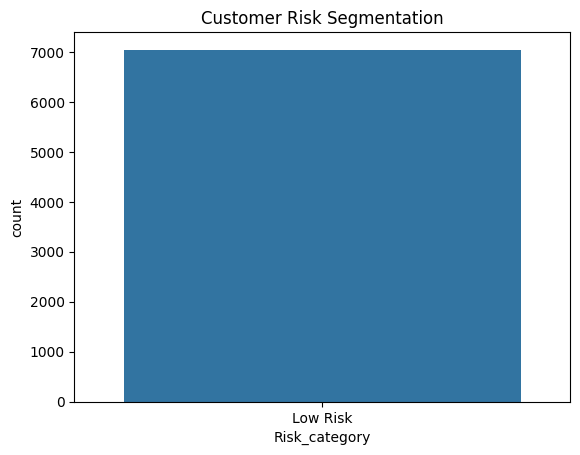

In [ ]:
sns.countplot(x='Risk_category', data=df)
plt.title("Customer Risk Segmentation")
plt.show()

In [ ]:
df['Risk_category'].value_counts()

,count
Risk_category,
Low Risk,7043


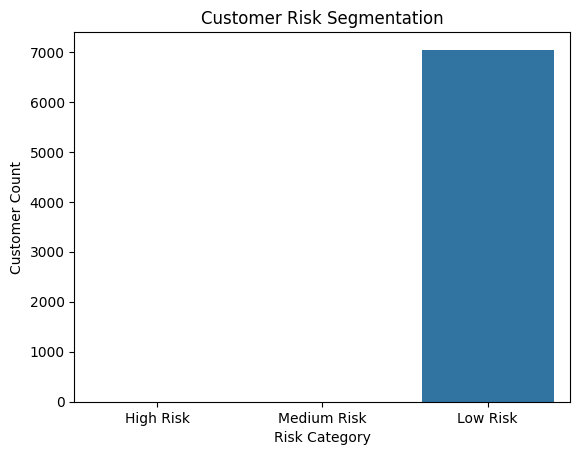

In [ ]:
sns.countplot(x='Risk_category', data=df, order=['High Risk','Medium Risk','Low Risk'])       #Shows how many customers fall into High / Medium / Low risk
plt.title("Customer Risk Segmentation")
plt.xlabel("Risk Category")
plt.ylabel("Customer Count")
plt.show()

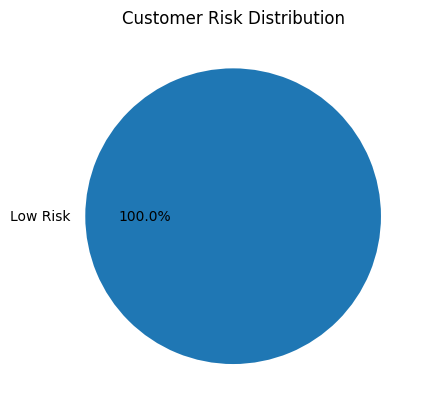

In [ ]:
df['Risk_category'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)                                                                                       #Pie Chart presentation

plt.title("Customer Risk Distribution")
plt.ylabel('')
plt.show()

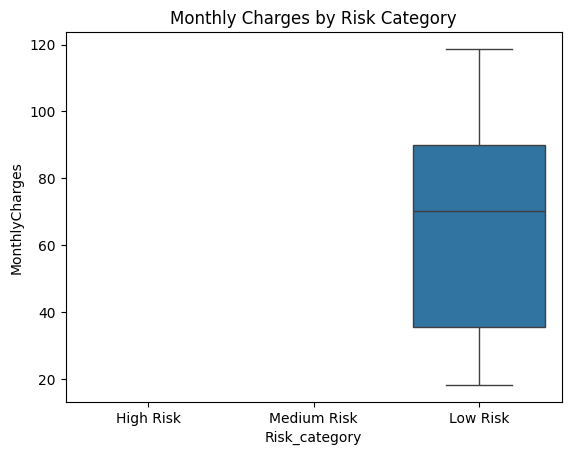

In [ ]:
sns.boxplot(x='Risk_category', y='MonthlyCharges', data=df,
            order=['High Risk','Medium Risk','Low Risk'])

plt.title("Monthly Charges by Risk Category")
plt.show()                                                                            #High-risk customers usually have higher charges

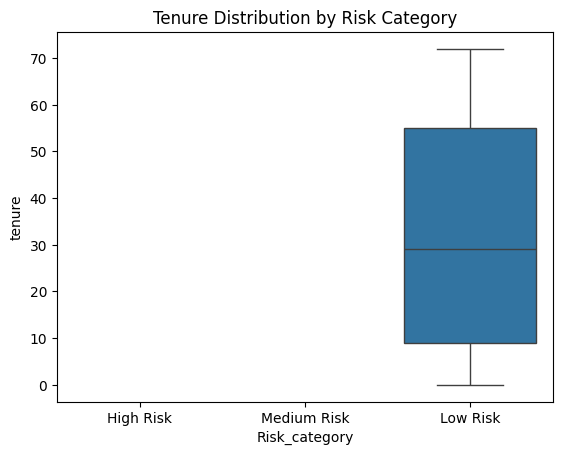

In [ ]:
sns.boxplot(x='Risk_category', y='tenure', data=df,
            order=['High Risk','Medium Risk','Low Risk'])                           #TENURE VS RISK
                                                                                    # High-risk → low tenure # Low-risk → higher tenure
plt.title("Tenure Distribution by Risk Category")
plt.show()